In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

df = pd.read_csv(r"D:\Data Science\uts\Proyek-Dashboard-Visualisasi-Data-Science\Dataset\fuel_prices_1970_2026_cleaned_and_classified.csv")

print(df.head())

         Date  Crude_Oil_Price  Year                Era
0  1970-01-01             1.21  1970  Era Of Oil Shocks
1  1970-02-01             1.21  1970  Era Of Oil Shocks
2  1970-03-01             1.21  1970  Era Of Oil Shocks
3  1970-04-01             1.21  1970  Era Of Oil Shocks
4  1970-05-01             1.21  1970  Era Of Oil Shocks


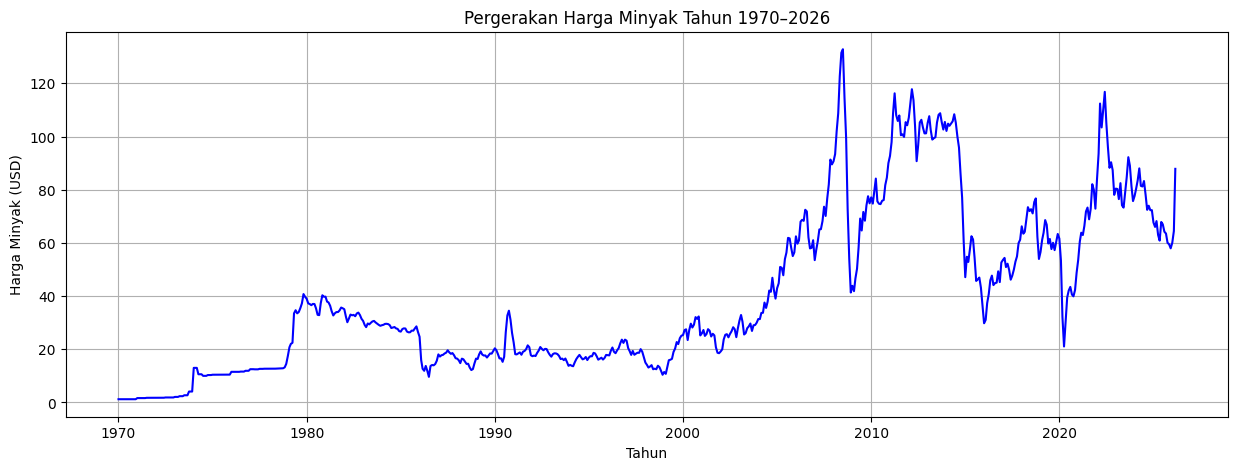

In [3]:
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')

# 1. Line Chart - Pergerakan Harga Minyak Tahun 1970–2026
plt.figure(figsize=(15,5))
plt.plot(df['Date'], df['Crude_Oil_Price'], color='blue')
plt.xlabel("Tahun")
plt.ylabel("Harga Minyak (USD)")
plt.title("Pergerakan Harga Minyak Tahun 1970–2026")
plt.grid()
plt.show()

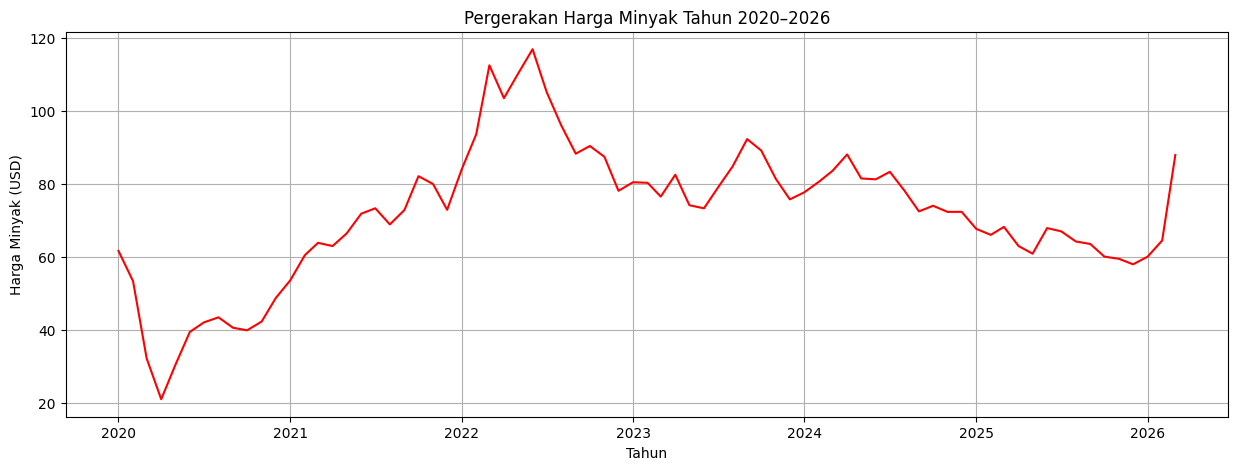

In [5]:
# Line Chart - Pergerakan Harga Minyak Tahun 2020–2026
df_filtered = df[(df['Date'].dt.year >= 2020) & (df['Date'].dt.year <= 2026)]
plt.figure(figsize=(15,5))
plt.plot(df_filtered['Date'], df_filtered['Crude_Oil_Price'], color='red')
plt.xlabel("Tahun")
plt.ylabel("Harga Minyak (USD)")
plt.title("Pergerakan Harga Minyak Tahun 2020–2026")
plt.grid()
plt.show()


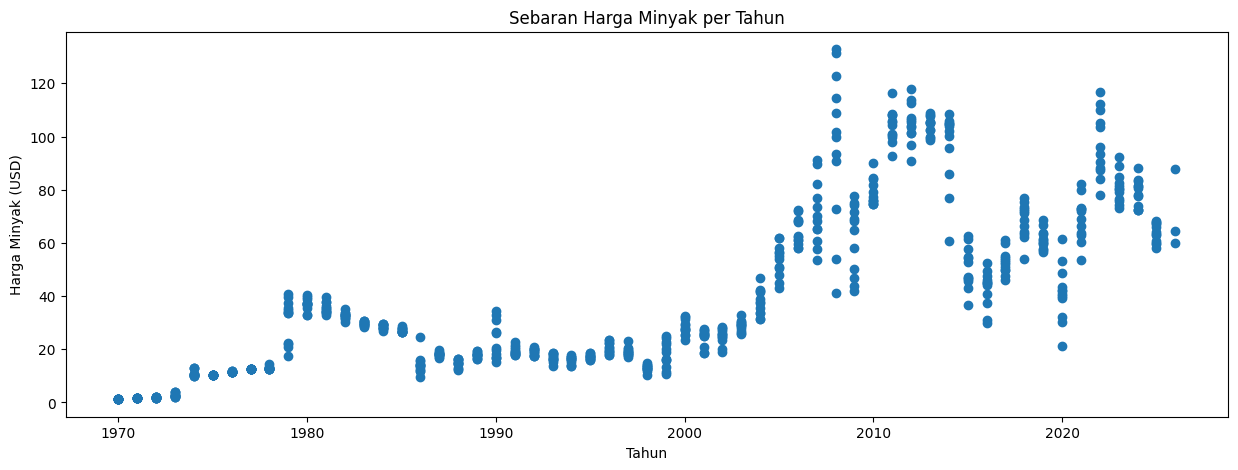

In [ ]:
# 2. Scatter Plot - Harga Minyak per tahun
plt.figure(figsize=(15,5))
plt.scatter(df['Year'], df['Crude_Oil_Price'])
plt.xlabel("Tahun")
plt.ylabel("Harga Minyak (USD)")
plt.title("Sebaran Harga Minyak per Tahun")
plt.show()

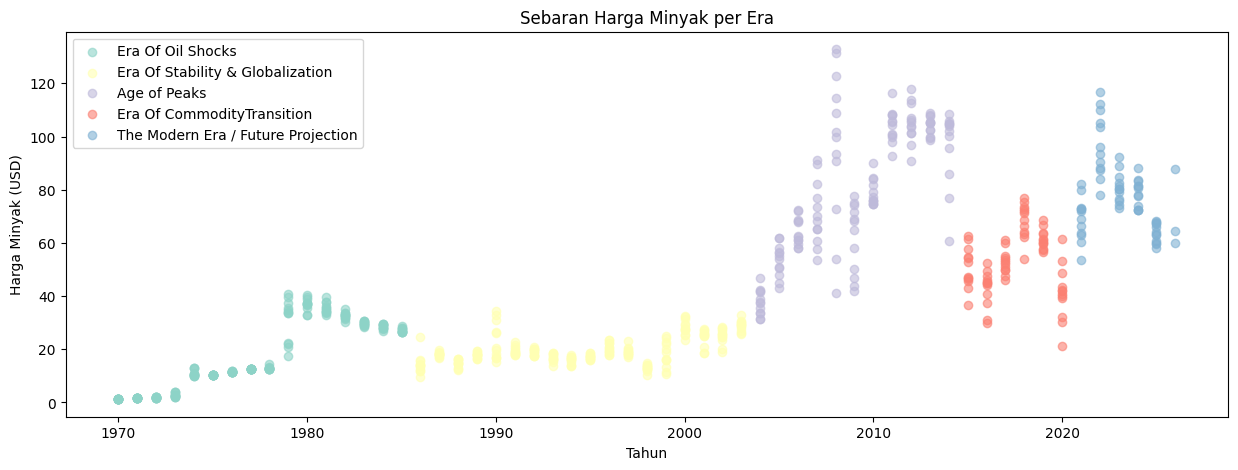

In [ ]:
# Scatter Plot - Harga Minyak per Era
plt.figure(figsize=(15,5))
eras = df['Era'].unique()
colors = plt.cm.Set3(np.arange(len(eras)))
for era, color in zip(eras, colors):
    subset = df[df['Era'] == era]
    plt.scatter(subset['Year'], subset['Crude_Oil_Price'], label=era, color=color, alpha=0.6)
plt.xlabel("Tahun")
plt.ylabel("Harga Minyak (USD)")
plt.title("Sebaran Harga Minyak per Era")
plt.legend()
plt.show()

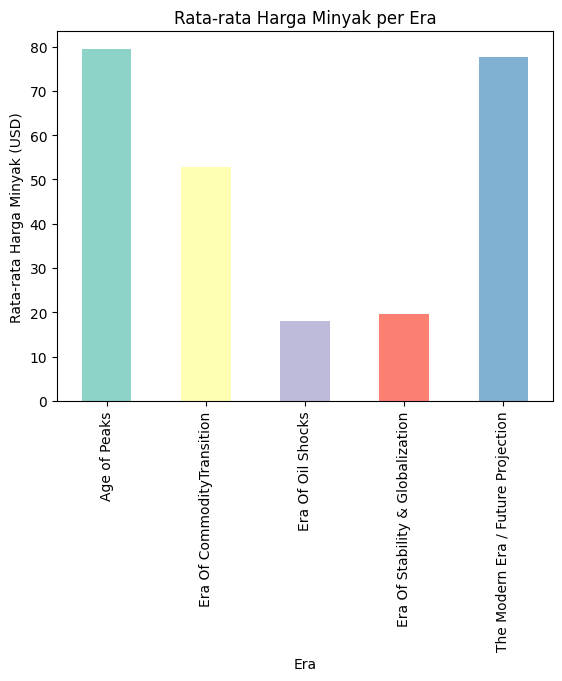

In [ ]:
# 3. Bar Chart - Rata-rata harga minyak per era
avg_per_era = df.groupby("Era")['Crude_Oil_Price'].mean()
avg_per_era.plot(kind='bar', color=plt.cm.Set3(np.arange(len(avg_per_era))))
plt.xlabel("Era")
plt.ylabel("Rata-rata Harga Minyak (USD)")
plt.title("Rata-rata Harga Minyak per Era")
plt.show()

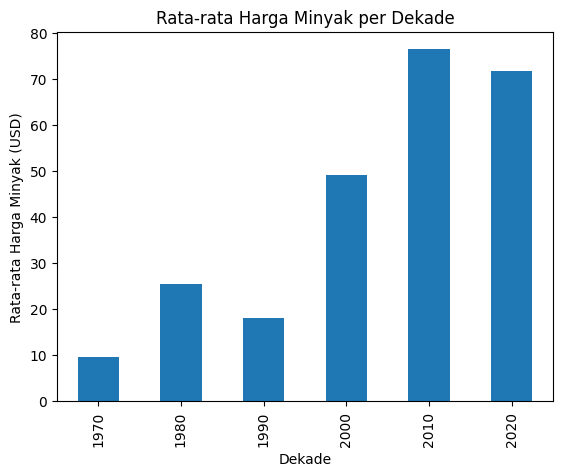

In [ ]:
#Rata- rata Rata-rata Harga Minyak per Dekade
df['Decade'] = (df['Year']//10)*10

avg_per_decade = df.groupby('Decade')['Crude_Oil_Price'].mean()
avg_per_decade.plot(kind='bar')
plt.title("Rata-rata Harga Minyak per Dekade")
plt.xlabel("Dekade")
plt.ylabel("Rata-rata Harga Minyak (USD)")
plt.show()

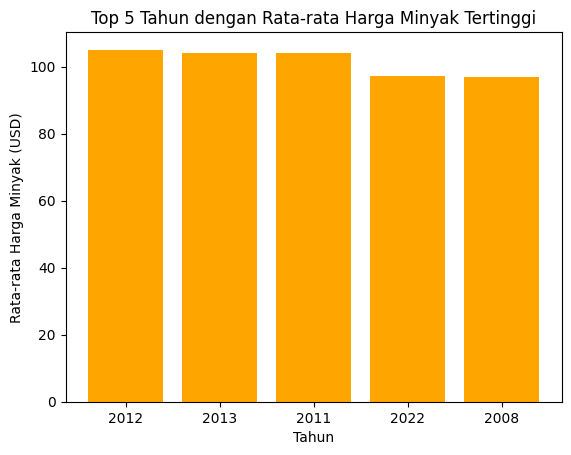

In [33]:
# Bar Chart - Top 5 Tahun dengan Rata-rata Harga Minyak Tertinggi
# Mengitung rata-rata harga per tahun
avg_per_year = df.groupby("Year")['Crude_Oil_Price'].mean()
top5 = avg_per_year.sort_values(ascending=False).head(5)

plt.bar(top5.index.astype(str), top5.values, color='orange')
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Harga Minyak (USD)")
plt.title("Top 5 Tahun dengan Rata-rata Harga Minyak Tertinggi")
plt.show()

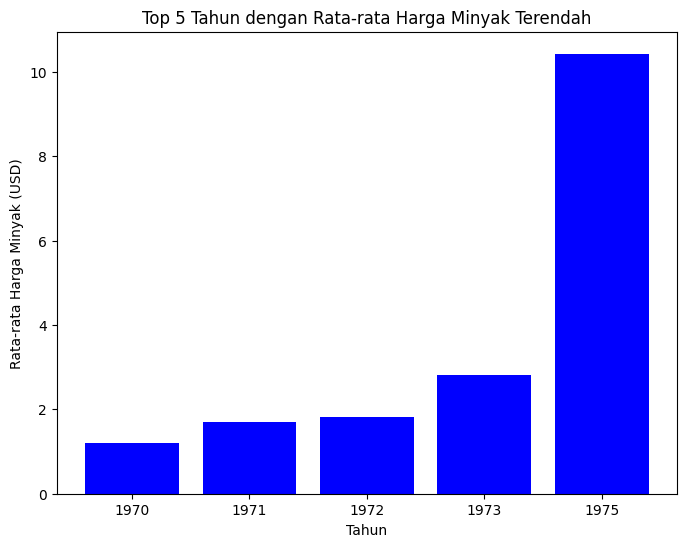

In [34]:
# Bar Chart - Top 5 Tahun dengan Rata-rata Harga Minyak terendah
# Menghitung rata-rata harga per tahun
avg_per_year = df.groupby("Year")['Crude_Oil_Price'].mean()
bottom5 = avg_per_year.sort_values(ascending=True).head(5)

plt.figure(figsize=(8,6))
plt.bar(bottom5.index.astype(str), bottom5.values, color='blue')
plt.xlabel("Tahun")
plt.ylabel("Rata-rata Harga Minyak (USD)")
plt.title("Top 5 Tahun dengan Rata-rata Harga Minyak Terendah")
plt.show()

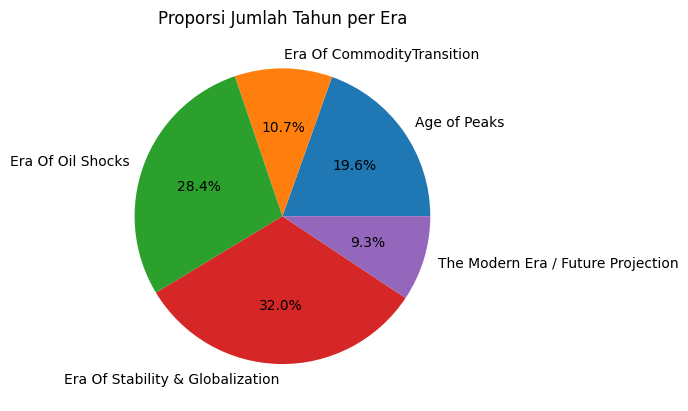

In [ ]:
# 4. Pie Chart - proporsi jumlah tahun per era
count_per_era = df.groupby("Era")['Year'].count()
count_per_era.plot(kind='pie', autopct='%1.1f%%')
plt.title("Proporsi Jumlah Tahun per Era")
plt.ylabel("")
plt.show()

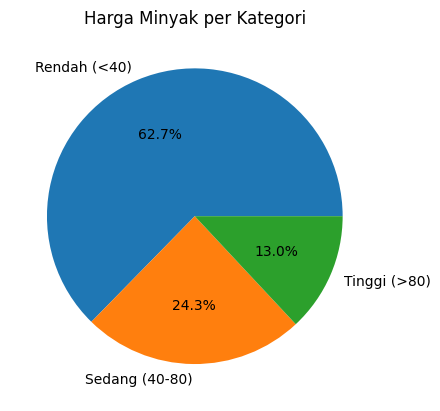

In [32]:
# Pie Chart - Proporsi harga minyak perkategori harga
subset = df
rendah = len(subset[subset['Crude_Oil_Price'] < 40])
sedang = len(subset[(subset['Crude_Oil_Price'] >= 40) & (subset['Crude_Oil_Price'] <= 80)])
tinggi = len(subset[subset['Crude_Oil_Price'] > 80])

nilai = [rendah, sedang, tinggi]
label = ['Rendah (<40)', 'Sedang (40-80)', 'Tinggi (>80)']

plt.pie(nilai, labels=label, autopct='%1.1f%%')
plt.title("Harga Minyak per Kategori")
plt.show()

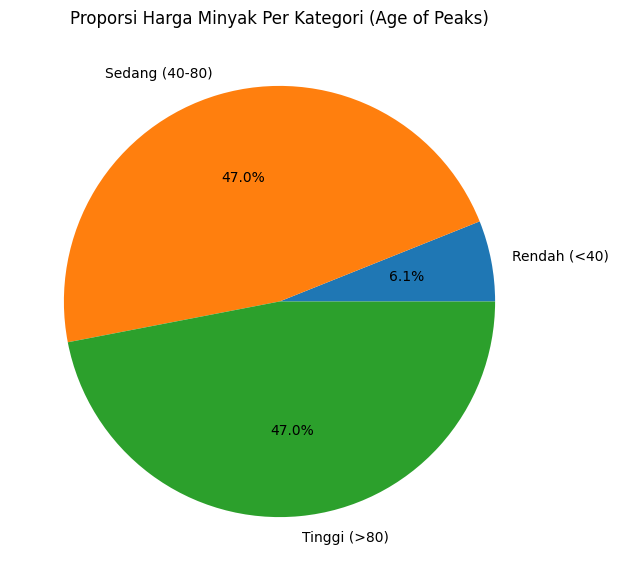

In [22]:
# Proporsi Harga Minyak Kategori  Age of Peaks
era = "Age of Peaks"
subset = df[df['Era'] == era]

rendah = len(subset[subset['Crude_Oil_Price'] < 40])
sedang = len(subset[(subset['Crude_Oil_Price'] >= 40) & (subset['Crude_Oil_Price'] <= 80)])
tinggi = len(subset[subset['Crude_Oil_Price'] > 80])

nilai = [rendah, sedang, tinggi]
label = ['Rendah (<40)', 'Sedang (40-80)', 'Tinggi (>80)']

plt.figure(figsize=(7,7))
plt.pie(nilai, labels=label, autopct='%1.1f%%')
plt.title(f"Proporsi Harga Minyak Per Kategori ({era})")
plt.show()

Text(0.5, 1.0, 'Proporsi Harga Minyak per Kategori (Tahun 2026)')

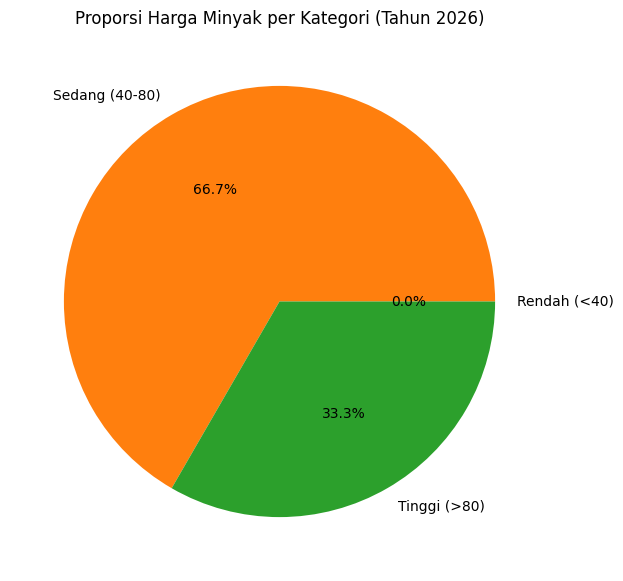

In [21]:
# Proporsi Harga Minyak per Kategori (Tahun 2026)
subset = df[df['Year'] == 2026]

rendah = len(subset[subset['Crude_Oil_Price'] < 40])
sedang = len(subset[(subset['Crude_Oil_Price'] >= 40) & (subset['Crude_Oil_Price'] <= 80)])
tinggi = len(subset[subset['Crude_Oil_Price'] > 80])

nilai = [rendah, sedang, tinggi]
label = ['Rendah (<40)', 'Sedang (40-80)', 'Tinggi (>80)']

plt.figure(figsize=(7,7))
plt.pie(nilai, labels=label, autopct='%1.1f%%')
plt.title("Proporsi Harga Minyak per Kategori (Tahun 2026)")

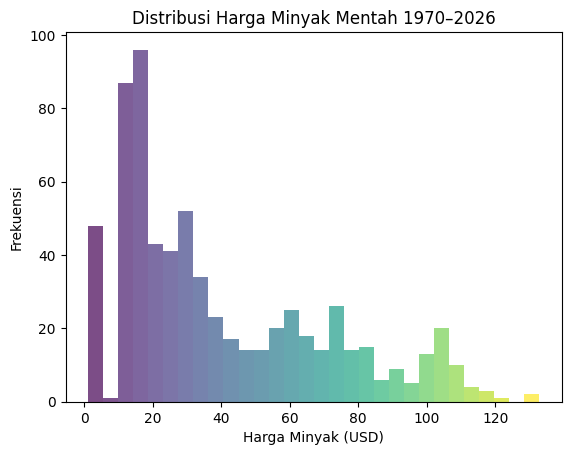

In [40]:
# 5. Histogram - Distribusi harga
counts, bins, patches = plt.hist(df['Crude_Oil_Price'], bins=30, alpha=0.7)
colors = plt.cm.viridis(np.linspace(0, 1, len(patches)))

for patch, color in zip(patches, colors):
    patch.set_facecolor(color)

plt.xlabel("Harga Minyak (USD)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Harga Minyak Mentah 1970–2026")
plt.show()

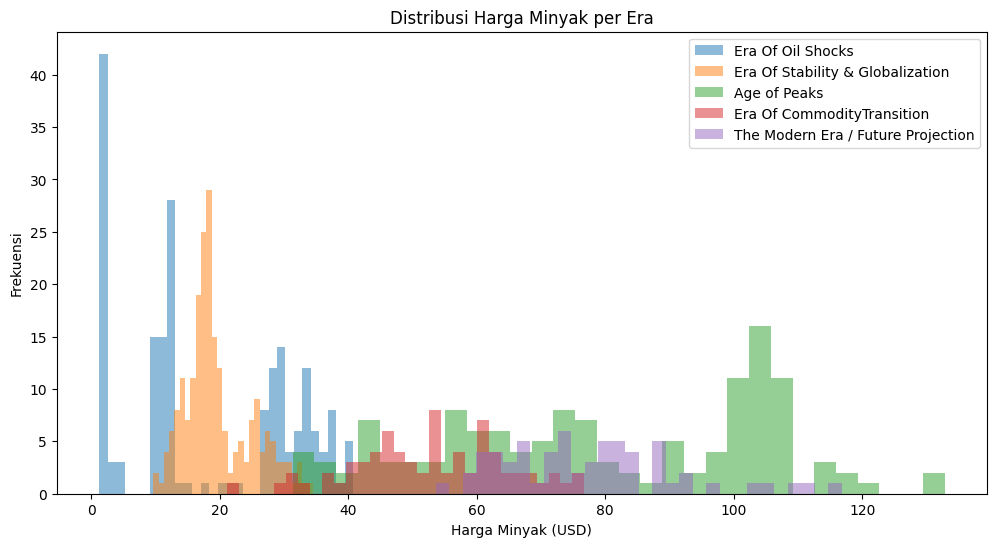

In [9]:
plt.figure(figsize=(12,6))

eras = df['Era'].unique()
for era in eras:
    subset = df[df['Era'] == era]
    plt.hist(subset['Crude_Oil_Price'], bins=30, alpha=0.5, label=era)

plt.xlabel("Harga Minyak (USD)")
plt.ylabel("Frekuensi")
plt.title("Distribusi Harga Minyak per Era")
plt.legend()
plt.show()